In [ ]:

import cv2
import torch
import numpy as np
from PIL import Image
from diffusers import StableDiffusionXLControlNetPipeline, ControlNetModel, AutoencoderKL
from diffusers.utils import load_image
from google.colab import files
import io

# 1. HELPER FUNCTION: PREPARE THE IMAGE
# This converts the handmade sketch into a "Canny" map (white lines on black bg)
# which helps the model understand the geometry of the Kolam.
def get_canny_image(image_path, low_threshold=100, high_threshold=200):
    image = load_image(image_path)
    image = np.array(image)

    # Get Canny edges
    image = cv2.Canny(image, low_threshold, high_threshold)
    image = image[:, :, None]
    image = np.concatenate([image, image, image], axis=2)
    canny_image = Image.fromarray(image)
    return canny_image

# 2. UPLOAD IMAGE FILE FUNCTION
def upload_image():
    """Upload an image file from your local machine"""
    print("Please upload your image file:")
    uploaded = files.upload()

    if not uploaded:
        raise ValueError("No file was uploaded!")

    # Get the filename and content
    filename = list(uploaded.keys())[0]
    content = uploaded[filename]

    # Save to a temporary path
    temp_path = f"/content/{filename}"
    with open(temp_path, 'wb') as f:
        f.write(content)

    print(f"✓ Image '{filename}' uploaded successfully!")
    return temp_path

# 3. LOAD CONTROLNET MODEL (SDXL specific)
print("Loading ControlNet model...")
controlnet = ControlNetModel.from_pretrained(
    "diffusers/controlnet-canny-sdxl-1.0",
    torch_dtype=torch.float16,
    use_safetensors=True
)

# 4. LOAD THE VAE (Optional, but recommended for SDXL quality)
print("Loading VAE...")
vae = AutoencoderKL.from_pretrained("madebyollin/sdxl-vae-fp16-fix", torch_dtype=torch.float16)

# 5. LOAD THE PIPELINE
print("Loading Stable Diffusion XL pipeline...")
pipe = StableDiffusionXLControlNetPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    controlnet=controlnet,
    vae=vae,
    torch_dtype=torch.float16,
    variant="fp16",
    use_safetensors=True
)

pipe.to("cuda")

# 6. LOAD YOUR FINE-TUNED LORA
print("Loading LoRA weights...")
lora_weights_path = "/content/pytorch_lora_weights.safetensors"
pipe.load_lora_weights(lora_weights_path, adapter_name="kolam_style")

print("\n✅ Setup complete! You can now run Cell 2 to upload images and generate results.")


Loading ControlNet model...


diffusion_pytorch_model.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

Loading VAE...


config.json:   0%|          | 0.00/631 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

...

unet/diffusion_pytorch_model.fp16.safete(…):   0%|          | 0.00/5.14G [00:00<?, ?B/s]

vae_1_0/diffusion_pytorch_model.fp16.saf(…):   0%|          | 0.00/167M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


Loading LoRA weights...

✅ Setup complete! You can now run Cell 2 to upload images and generate results.


Image section


Generating image...


  0%|          | 0/50 [00:00<?, ?it/s]

✅ Done! Results saved.


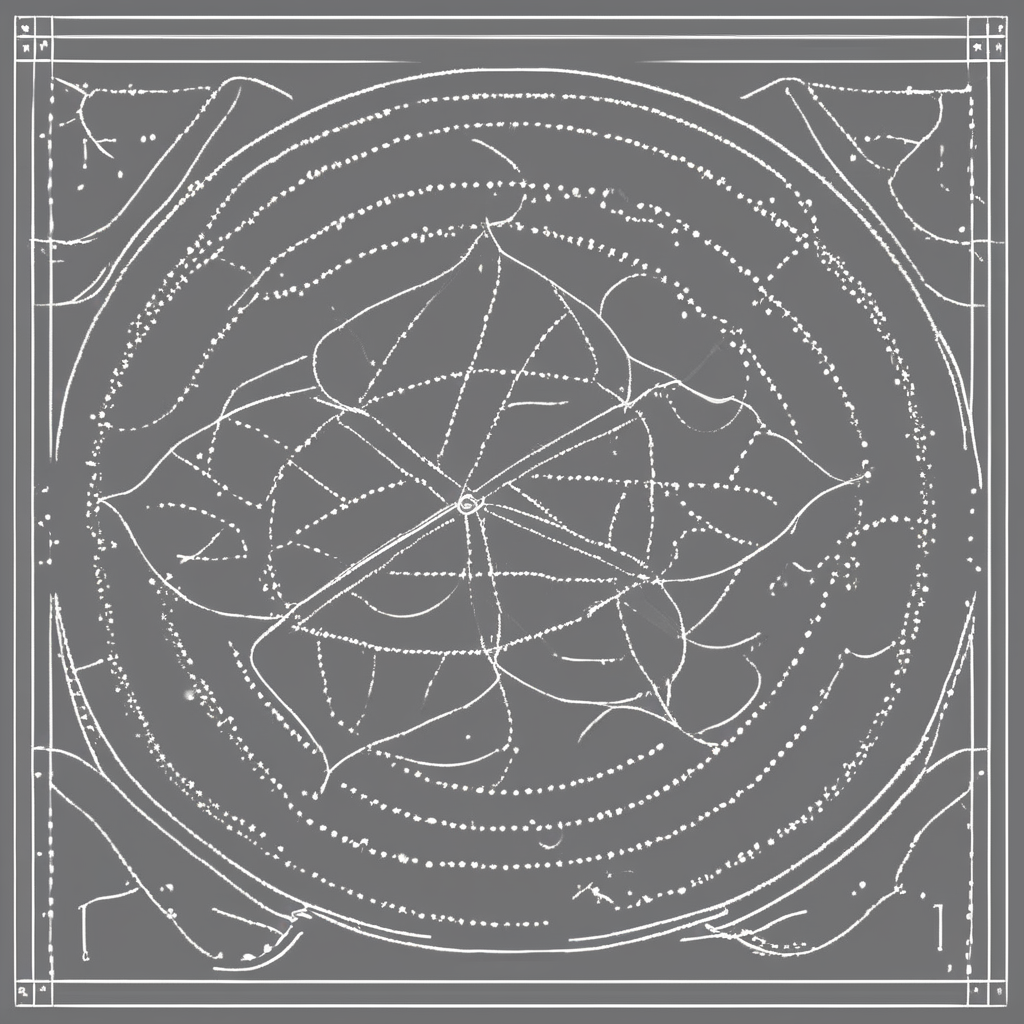

In [ ]:
# Upload your image
# input_image_path = '/content/rangoli 1.png'
input_image_path = '/content/1000089872.jpg'

# Prepare the image for ControlNet
control_image = get_canny_image(input_image_path)

# Resize for best SDXL performance
control_image = control_image.resize((1024, 1024))

# OPTION 1: Minimal changes - Best for keeping original design
# prompt = "kolam design, clean lines, slightly enhanced, same pattern, minimal details, elegant"
# negative_prompt = "complex, extra patterns, added elements, busy, intricate, ornate, different design"

# OPTION 2: Light enhancement - Subtle improvements only
# prompt = "simple kolam pattern, clean black lines, refined edges, same structure, minimal embellishment"
# negative_prompt = "complicated, added decorations, extra details, changed pattern, complex design, flowery"

# OPTION 3: Preserve original - Strongest control (RECOMMENDED)
# prompt = "kolam, preserve original pattern, clean lines, minimal changes, same design, subtle refinement only"
# negative_prompt = "added patterns, complex details, extra elements, different design, intricate, ornate, busy"

# OPTION 4: Simple refinement
prompt = "refined kolam design reconstructed from the input pattern, same structure preserved, smooth and uniform strokes, corrected symmetry, cleaned dot-grid alignment, improved geometry, vector-like clean outline, balanced proportions, neat adult-drawn appearance, minimal detailing, black-and-white high-quality line art, consistent stroke weight, polished and precise but simple"
negative_prompt = "added complexity, extra motifs, ornamental details, dense patterns, mandala-level intricacy, new shapes not in input, double lines, shading, gradients, sketch texture, jittery strokes, rough edges, distortions, blur, noise, artifacts, uneven lines, overly artistic effects, 3D rendering, heavy textures"

# Generate the image
# REDUCED controlnet_conditioning_scale to follow input more strictly
print("Generating image...")
image = pipe(
    prompt,
    negative_prompt=negative_prompt,
    image=control_image,
    controlnet_conditioning_scale=0.7,  # Increased to 0.7 for stricter adherence to original
    cross_attention_kwargs={"scale": 0.5}  # Reduced LoRA strength to 0.5
).images[0]

# Save results
control_image.save("/content/debug_canny_input.png")
image.save("/content/kolam_result4.png")

print("✅ Done! Results saved.")
display(image)  # Display in Colab